# Chapitre 7 — Statistique inférentielle

**Cours : Analyse et traitement des données** · Auteur : *Issa Gueye*

## Objectifs

- Passer de l'**échantillon** à la **population** : estimation, intervalle de confiance, test.
- Choisir le **test adapté** (t de Student, Mann–Whitney, ANOVA, Kruskal–Wallis, χ²).
- Interpréter correctement une **p-valeur** et une **taille d'effet**.
- Utiliser le **bootstrap** et corriger les **tests multiples**.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

DATA = next(p for p in [Path("data/brutes"), Path("../data/brutes"), Path("../../data/brutes")] if p.exists())
sns.set_theme(style="whitegrid", palette="colorblind")
etu = pd.read_csv(DATA / "resultats_etudiants.csv")
rng = np.random.default_rng(7)
etu.head(3)

,id_etudiant,filiere,sexe,heures_etude_semaine,tutorat,note_controle_continu,note_examen,admis
0,E2000,Informatique,F,2.5,Non,12.89,12.88,Oui
1,E2001,Mathématiques,M,14.2,Oui,6.51,11.54,Oui
2,E2002,Biologie,F,10.3,Oui,12.48,13.48,Oui


## 1. Échantillon, population, distribution d'échantillonnage

On observe un **échantillon** ; on veut parler de la **population**. Une statistique (ex. la moyenne $\bar x$)
varie d'un échantillon à l'autre : sa loi est la **distribution d'échantillonnage**.

**Théorème central limite (TCL)** : pour $n$ assez grand, $\bar X \approx \mathcal N\!\left(\mu, \sigma^2/n\right)$,
**quelle que soit** la loi des observations (si la variance est finie). L'**erreur standard** est $\mathrm{SE} = \sigma/\sqrt n$.

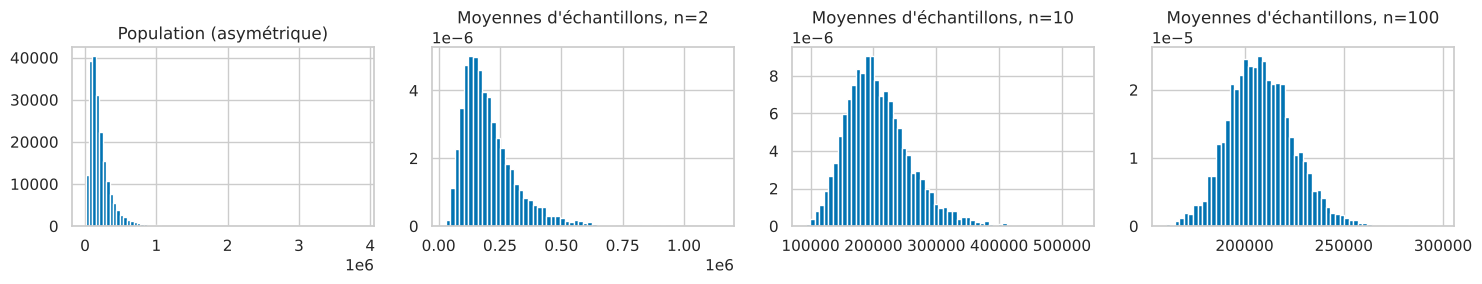

In [2]:
population = rng.lognormal(mean=12, sigma=0.7, size=200_000)      # « revenus » très asymétriques
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes[0].hist(population, bins=80); axes[0].set_title("Population (asymétrique)")
for ax, n in zip(axes[1:], [2, 10, 100]):
    moyennes = rng.choice(population, size=(5_000, n)).mean(axis=1)
    ax.hist(moyennes, bins=60, density=True)
    ax.set_title(f"Moyennes d'échantillons, n={n}")
plt.tight_layout(); plt.show()

## 2. Intervalle de confiance (IC)

IC à 95 % pour une moyenne (loi de Student, variance inconnue) :
$$\bar x \pm t_{0{,}975;\,n-1}\,\frac{s}{\sqrt n}$$

**Interprétation correcte** : si l'on répétait l'enquête un grand nombre de fois, **95 % des intervalles
ainsi construits** contiendraient la vraie moyenne. (Ce n'est **pas** « 95 % de chance que μ soit dans *cet* intervalle ».)

In [3]:
x = etu["note_examen"]
moy, se = x.mean(), stats.sem(x)
ic = stats.t.interval(0.95, df=len(x) - 1, loc=moy, scale=se)
print(f"Moyenne = {moy:.2f}, SE = {se:.3f}, IC95% = [{ic[0]:.2f} ; {ic[1]:.2f}]")

Moyenne = 11.45, SE = 0.108, IC95% = [11.24 ; 11.67]


Simulation de la couverture : 100 IC sur des échantillons de taille 30.

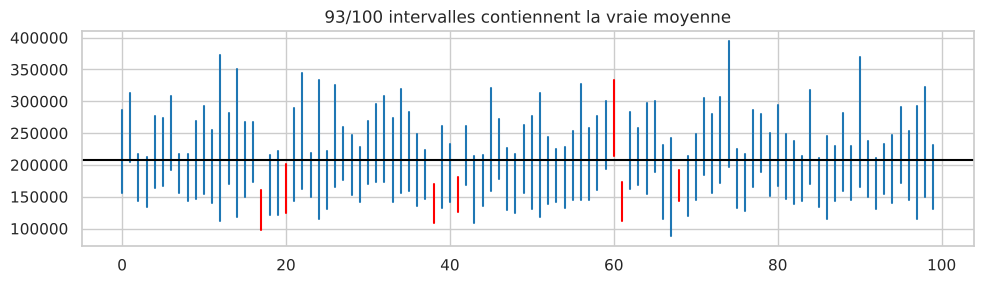

In [4]:
mu_vrai = population.mean()
fig, ax = plt.subplots(figsize=(10, 3))
rate = 0
for i in range(100):
    e = rng.choice(population, 30)
    lo, hi = stats.t.interval(0.95, 29, e.mean(), stats.sem(e))
    contient = lo <= mu_vrai <= hi
    rate += contient
    ax.plot([i, i], [lo, hi], color="tab:blue" if contient else "red")
ax.axhline(mu_vrai, color="black"); ax.set_title(f"{rate}/100 intervalles contiennent la vraie moyenne")
plt.tight_layout(); plt.show()

Proportion : $\hat p \pm z_{0{,}975}\sqrt{\hat p(1-\hat p)/n}$ (méthode de Wald) — on préfère l'intervalle de
**Wilson**, plus fiable pour les petites proportions.

In [5]:
from statsmodels.stats.proportion import proportion_confint

k, n = (etu["admis"] == "Oui").sum(), len(etu)
print("Taux d'admission :", round(k / n, 3), "| IC95% Wilson :", np.round(proportion_confint(k, n, method="wilson"), 3))

Taux d'admission : 0.703 | IC95% Wilson : [0.666 0.738]


## 3. Logique d'un test d'hypothèse

1. **H₀** (hypothèse nulle, « pas d'effet ») et **H₁** (alternative).
2. Choisir un seuil **α** (souvent 5 %) *avant* de regarder les données.
3. Calculer une **statistique de test** et sa **p-valeur** : probabilité, **si H₀ est vraie**,
   d'observer un résultat au moins aussi extrême.
4. Si $p < α$ : on **rejette H₀** ; sinon on **ne rejette pas** (≠ « H₀ est prouvée »).

|  | H₀ vraie | H₀ fausse |
|---|---|---|
| Rejeter H₀ | **Erreur de type I** (α) | ✅ puissance $1-β$ |
| Ne pas rejeter | ✅ | **Erreur de type II** (β) |

> ⚠️ Une p-valeur **ne mesure pas** l'importance d'un effet. Avec $n$ très grand, un effet minuscule devient
> « significatif ». **Toujours rapporter une taille d'effet et un IC** (déclaration de l'ASA, Wasserstein & Lazar, 2016).

## 4. Comparer deux groupes

**Question** : le tutorat améliore-t-il la note d'examen ?

In [6]:
avec = etu.loc[etu["tutorat"] == "Oui", "note_examen"]
sans = etu.loc[etu["tutorat"] == "Non", "note_examen"]
print(f"avec tutorat : n={len(avec)}, moyenne={avec.mean():.2f} | sans : n={len(sans)}, moyenne={sans.mean():.2f}")

avec tutorat : n=203, moyenne=12.02 | sans : n=397, moyenne=11.17


### 4.1 Vérifier les conditions
Le test t suppose des observations **indépendantes** et des moyennes approximativement normales
(vrai par le TCL si $n$ ≳ 30 par groupe). On utilise par défaut la version de **Welch** (variances inégales).

In [7]:
print("Shapiro (normalité) p =", round(stats.shapiro(avec).pvalue, 3), "/", round(stats.shapiro(sans).pvalue, 3))
print("Levene (égalité des variances) p =", round(stats.levene(avec, sans).pvalue, 3))

Shapiro (normalité) p = 0.952 / 0.044
Levene (égalité des variances) p = 0.516


### 4.2 Test t de Welch + taille d'effet (d de Cohen)
$$d = \frac{\bar x_1 - \bar x_2}{s_{\text{poolé}}}\quad(0{,}2 \text{ petit}, 0{,}5 \text{ moyen}, 0{,}8 \text{ grand — repères de Cohen})$$

In [8]:
res = stats.ttest_ind(avec, sans, equal_var=False)
ic_diff = res.confidence_interval(0.95)
s_pool = np.sqrt(((len(avec) - 1) * avec.var() + (len(sans) - 1) * sans.var()) / (len(avec) + len(sans) - 2))
d = (avec.mean() - sans.mean()) / s_pool
print(f"t = {res.statistic:.2f}, p = {res.pvalue:.2e}")
print(f"différence = {avec.mean() - sans.mean():.2f} points, IC95% = [{ic_diff.low:.2f} ; {ic_diff.high:.2f}]")
print(f"d de Cohen = {d:.2f}")

t = 3.69, p = 2.53e-04
différence = 0.85 points, IC95% = [0.40 ; 1.30]
d de Cohen = 0.33


**Conclusion rédigée** : les étudiants avec tutorat obtiennent en moyenne ≈ 1 point de plus (IC95 % donné ci-dessus),
différence statistiquement significative et d'ampleur modérée. ⚠️ Étude **observationnelle** : on ne peut conclure à
un effet **causal** du tutorat (ceux qui le choisissent sont peut-être plus motivés).

### 4.3 Alternative non paramétrique : Mann–Whitney (Wilcoxon rang-somme)
Utile pour des données ordinales, très asymétriques ou de petits échantillons.

In [9]:
mw = stats.mannwhitneyu(avec, sans, alternative="two-sided")
print(f"U = {mw.statistic:.0f}, p = {mw.pvalue:.2e}")

U = 47008, p = 8.35e-04


### 4.4 Données appariées
Mêmes étudiants mesurés deux fois (contrôle continu puis examen) → test t **apparié** (ou Wilcoxon signé).

In [10]:
ap = stats.ttest_rel(etu["note_examen"], etu["note_controle_continu"])
print(f"gain moyen = {(etu['note_examen'] - etu['note_controle_continu']).mean():.2f}, p = {ap.pvalue:.2e}")

gain moyen = 1.13, p = 1.56e-24


## 5. Plus de deux groupes : ANOVA et Kruskal–Wallis

**Question** : la note moyenne diffère-t-elle selon la filière ?

In [11]:
groupes = [g["note_examen"].values for _, g in etu.groupby("filiere")]
an = stats.f_oneway(*groupes)
kw = stats.kruskal(*groupes)
print(f"ANOVA : F = {an.statistic:.2f}, p = {an.pvalue:.3g} | Kruskal–Wallis : H = {kw.statistic:.2f}, p = {kw.pvalue:.3g}")

# η² (part de variance expliquée par la filière)
grand = etu["note_examen"].mean()
sce_inter = sum(len(g) * (g.mean() - grand) ** 2 for g in groupes)
sce_tot = ((etu["note_examen"] - grand) ** 2).sum()
print(f"η² = {sce_inter / sce_tot:.3f}")

ANOVA : F = 13.47, p = 1.63e-08 | Kruskal–Wallis : H = 36.72, p = 5.27e-08
η² = 0.063


L'ANOVA dit « au moins une moyenne diffère », pas laquelle → **comparaisons post-hoc** (Tukey HSD) :

In [12]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print(pairwise_tukeyhsd(etu["note_examen"], etu["filiere"], alpha=0.05))

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
     Biologie  Informatique   0.0293 0.9997 -0.7527  0.8112  False
     Biologie Mathématiques  -1.1055 0.0009 -1.8515 -0.3594   True
     Biologie      Économie   0.6899 0.1008 -0.0852  1.4649  False
 Informatique Mathématiques  -1.1347 0.0007 -1.8879 -0.3816   True
 Informatique      Économie   0.6606  0.131 -0.1214  1.4425  False
Mathématiques      Économie   1.7953    0.0  1.0493  2.5413   True
------------------------------------------------------------------


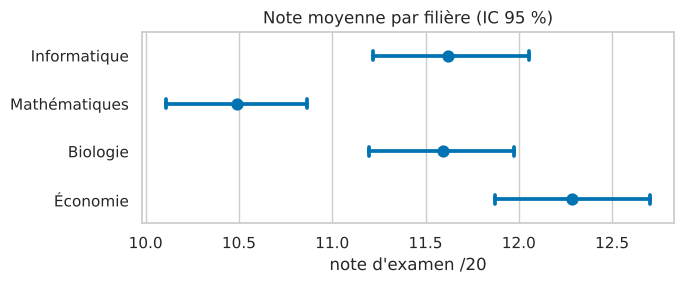

In [13]:
fig, ax = plt.subplots(figsize=(7, 3))
sns.pointplot(data=etu, x="note_examen", y="filiere", errorbar=("ci", 95), linestyle="none", capsize=0.2, ax=ax)
ax.set(title="Note moyenne par filière (IC 95 %)", xlabel="note d'examen /20", ylabel="")
plt.tight_layout(); plt.show()

## 6. Deux variables qualitatives : test du χ² d'indépendance

**Question** : l'accès à internet est-il indépendant du milieu (urbain/rural) ?

In [14]:
menages = pd.read_csv(DATA / "enquete_menages.csv")
tab = pd.crosstab(menages["milieu"], menages["acces_internet"])
chi2, p, ddl, attendus = stats.chi2_contingency(tab)
n = tab.values.sum()
v_cramer = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))
print(tab, "\n")
print(f"χ² = {chi2:.1f}, ddl = {ddl}, p = {p:.2e}, V de Cramér = {v_cramer:.2f}")
print("Effectifs attendus tous ≥ 5 :", (attendus >= 5).all())

acces_internet   Non   Oui
milieu                    
Rural           1015   283
Urbain           641  1061 

χ² = 487.7, ddl = 1, p = 4.61e-108, V de Cramér = 0.40
Effectifs attendus tous ≥ 5 : True


Condition : effectifs **attendus** ≥ 5 ; sinon test **exact de Fisher** (`stats.fisher_exact` pour un tableau 2×2).

## 7. Tester une corrélation

In [15]:
r, p_r = stats.pearsonr(etu["heures_etude_semaine"], etu["note_examen"])
rho, p_s = stats.spearmanr(etu["heures_etude_semaine"], etu["note_examen"])
print(f"Pearson r = {r:.3f} (p = {p_r:.1e}) | Spearman ρ = {rho:.3f} (p = {p_s:.1e})")

Pearson r = 0.196 (p = 1.3e-06) | Spearman ρ = 0.187 (p = 4.0e-06)


## 8. Le bootstrap : un IC pour (presque) n'importe quelle statistique

Idée (Efron, 1979) : ré-échantillonner **avec remise** les données observées pour approcher la distribution
d'échantillonnage. Très utile pour la **médiane**, un ratio, un écart de médianes…

In [16]:
rev = menages["revenu_mensuel_fcfa"].dropna()
urb, rur = rev[menages["milieu"] == "Urbain"], rev[menages["milieu"] == "Rural"]

def ecart_medianes(a, b):
    return np.median(a) - np.median(b)

boot = stats.bootstrap((urb.values, rur.values), ecart_medianes, n_resamples=5_000, method="percentile",
                       random_state=0, vectorized=False)
print(f"écart de médianes urbain − rural = {ecart_medianes(urb, rur):,.0f} FCFA")
print(f"IC95% bootstrap = [{boot.confidence_interval.low:,.0f} ; {boot.confidence_interval.high:,.0f}]")

écart de médianes urbain − rural = 122,500 FCFA
IC95% bootstrap = [108,000 ; 136,000]


## 9. Tests multiples

Avec 20 tests indépendants au seuil 5 %, la probabilité d'au moins un faux positif est $1 - 0{,}95^{20} ≈ 64\%$ !

- **Bonferroni** : seuil α/m (très conservateur) — contrôle le risque d'**au moins une** erreur (FWER).
- **Benjamini–Hochberg** : contrôle le **taux de fausses découvertes** (FDR), plus puissant ; standard en génomique.

In [17]:
from statsmodels.stats.multitest import multipletests

# 20 comparaisons « bidons » (aucune vraie différence) + 3 vraies différences
p_vals = [stats.ttest_ind(rng.normal(0, 1, 50), rng.normal(0, 1, 50)).pvalue for _ in range(20)]
p_vals += [stats.ttest_ind(rng.normal(0, 1, 50), rng.normal(0.8, 1, 50)).pvalue for _ in range(3)]
for methode in ["bonferroni", "fdr_bh"]:
    rejet, *_ = multipletests(p_vals, alpha=0.05, method=methode)
    print(f"{methode:<11}: {rejet.sum()} rejets (dont {rejet[:20].sum()} faux positifs)")
print(f"sans correction : {(np.array(p_vals) < 0.05).sum()} rejets (dont {(np.array(p_vals[:20]) < 0.05).sum()} faux positifs)")

bonferroni : 2 rejets (dont 0 faux positifs)
fdr_bh     : 2 rejets (dont 0 faux positifs)
sans correction : 2 rejets (dont 0 faux positifs)


## 10. Arbre de décision : quel test choisir ?

```text
Quelles variables ?
├── 1 quanti vs 1 quali à 2 groupes
│     ├── indépendants : t de Welch      (non param. : Mann–Whitney)
│     └── appariés     : t apparié       (non param. : Wilcoxon signé)
├── 1 quanti vs 1 quali à ≥3 groupes : ANOVA + Tukey   (non param. : Kruskal–Wallis + Dunn)
├── 2 quali : χ² d'indépendance        (petits effectifs : Fisher exact)
└── 2 quanti : corrélation de Pearson  (monotone / extrêmes : Spearman) → régression (chap. 9)
```

## À retenir

- IC et test sont deux faces de la même inférence ; **rapporter les deux + une taille d'effet**.
- p-valeur = compatibilité des données avec H₀, **pas** la probabilité que H₀ soit vraie.
- Vérifier les **conditions** (indépendance, normalité approchée, effectifs attendus).
- Corriger les **tests multiples** ; ne pas « pêcher » la significativité (*p-hacking*).
- Données observationnelles : **association ≠ causalité**.

**Références** : Wasserstein R. & Lazar N. (2016), « The ASA Statement on p-Values », *The American Statistician* 70(2) ;
Efron B. & Tibshirani R. (1993), *An Introduction to the Bootstrap* ; Benjamini Y. & Hochberg Y. (1995), *JRSS B* 57(1) ;
Cohen J. (1988), *Statistical Power Analysis for the Behavioral Sciences*.

➡️ **Chapitre suivant : préparer les données pour la modélisation (feature engineering).**